# Fine-tuning DistilBERT — Klasifikasi Sentimen 3 Kelas

Input: `data/splits/train.csv`, `val.csv`, `test.csv` dari notebook 03.

Model `distilbert-base-uncased` di-fine-tune untuk klasifikasi:
- 0 = Negatif (bintang 1–2)
- 1 = Netral (bintang 3)
- 2 = Positif (bintang 4–5)

Output: model di `models/distilbert/`, metrik di `outputs/metrics/`.

## 0. Import Library

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from datasets import load_dataset

BASE_DIR     = r"D:\big-data-ai-sentiment"
PATH_SPLIT   = os.path.join(BASE_DIR, "data", "splits")
PATH_MODEL   = os.path.join(BASE_DIR, "models", "distilbert")
PATH_METRICS = os.path.join(BASE_DIR, "outputs", "metrics")
PATH_FIG     = os.path.join(BASE_DIR, "outputs", "figures")
HF_CACHE     = r"D:\hf-cache"

for p in [PATH_MODEL, PATH_METRICS, HF_CACHE]:
    os.makedirs(p, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device  : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("PERINGATAN: tidak ada GPU — training di CPU akan sangat lambat.")

print("Import selesai.")

Device  : cuda
GPU     : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM    : 6.0 GB
Import selesai.


## 1. Load Data & Konfigurasi

In [2]:
MAX_LENGTH   = 512
BATCH_SIZE   = 8
EPOCHS       = 3
LR           = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
LABEL_MAP    = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}

# Baca header saja untuk cek jumlah baris
df_train = pd.read_csv(os.path.join(PATH_SPLIT, 'train.csv'), usecols=['sentiment'])
df_val   = pd.read_csv(os.path.join(PATH_SPLIT, 'val.csv'),   usecols=['sentiment'])
df_test  = pd.read_csv(os.path.join(PATH_SPLIT, 'test.csv'),  usecols=['sentiment'])

n_train, n_val, n_test = len(df_train), len(df_val), len(df_test)
del df_train, df_val, df_test  # bebaskan RAM

print(f"Train : {n_train:,} baris")
print(f"Val   : {n_val:,} baris")
print(f"Test  : {n_test:,} baris")

steps_per_epoch = n_train // BATCH_SIZE
total_steps     = steps_per_epoch * EPOCHS
print(f"\nSteps per epoch : {steps_per_epoch:,}")
print(f"Total steps     : {total_steps:,}")
print(f"\nKonfigurasi training:")
print(f"  max_length   = {MAX_LENGTH}")
print(f"  batch_size   = {BATCH_SIZE}")
print(f"  epochs       = {EPOCHS}")
print(f"  lr           = {LR}")
print(f"  weight_decay = {WEIGHT_DECAY}")
print(f"  warmup_ratio = {WARMUP_RATIO}")

Train : 4,893,189 baris
Val   : 1,048,541 baris
Test  : 1,048,541 baris

Steps per epoch : 611,648
Total steps     : 1,834,944

Konfigurasi training:
  max_length   = 512
  batch_size   = 8
  epochs       = 3
  lr           = 2e-05
  weight_decay = 0.01
  warmup_ratio = 0.1


## 2. Tokenisasi Dataset

Tokenisasi dilakukan sekali di sini, bukan di setiap batch — lebih efisien. Padding tidak dilakukan di sini, melainkan saat collation (dynamic padding per batch lewat `DataCollatorWithPadding`).

In [3]:
print("Memuat tokenizer...")
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize_fn(batch):
    return tokenizer(
        batch['text_clean'],
        max_length=MAX_LENGTH,
        truncation=True,
        padding=False,
    )

def load_and_tokenize(csv_path, split_name):
    print(f"  Loading {split_name} dari CSV...")
    ds = load_dataset(
        'csv',
        data_files=csv_path,
        split='train',
        cache_dir=HF_CACHE,
    )
    ds = ds.rename_column('sentiment', 'labels')
    print(f"  Tokenisasi {split_name} ({len(ds):,} baris)...")
    ds = ds.map(
        tokenize_fn,
        batched=True,
        batch_size=1000,
        desc=f"Tokenizing {split_name}",
    )
    ds = ds.remove_columns([c for c in ds.column_names if c not in ('input_ids', 'attention_mask', 'labels')])
    ds.set_format('torch')
    return ds

print("Memuat dan tokenisasi dataset (Arrow cache ke D:\\hf-cache)...")
train_ds = load_and_tokenize(os.path.join(PATH_SPLIT, 'train.csv'), 'train')
val_ds   = load_and_tokenize(os.path.join(PATH_SPLIT, 'val.csv'),   'val')
test_ds  = load_and_tokenize(os.path.join(PATH_SPLIT, 'test.csv'),  'test')

print(f"\nFitur dataset : {list(train_ds[0].keys())}")
print("Tokenisasi selesai.")

Memuat tokenizer...


Memuat dan tokenisasi dataset (Arrow cache ke D:\hf-cache)...
  Loading train dari CSV...
  Tokenisasi train (4,893,189 baris)...
  Loading val dari CSV...
  Tokenisasi val (1,048,541 baris)...
  Loading test dari CSV...
  Tokenisasi test (1,048,541 baris)...

Fitur dataset : ['labels', 'input_ids', 'attention_mask']
Tokenisasi selesai.


## 3. Load Model

Classifier head (layer terakhir) diinisialisasi acak dan akan dilatih dari awal. Lapisan transformer DistilBERT di-fine-tune dari pre-trained weights.

In [4]:
print("Memuat distilbert-base-uncased...")
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3,
    id2label={0: 'Negatif', 1: 'Netral', 2: 'Positif'},
    label2id={'Negatif': 0, 'Netral': 1, 'Positif': 2},
    ignore_mismatched_sizes=True,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameter     : {total_params:,}")
print(f"Trainable parameter : {trainable_params:,}")

Memuat distilbert-base-uncased...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameter     : 66,955,779
Trainable parameter : 66,955,779


## 4. Training

Fine-tuning 3 epoch dengan early stopping (patience=2). Model terbaik berdasarkan weighted F1 di validation set yang akan disimpan.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1':       f1_score(labels, preds, average='weighted'),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

warmup_steps = int(WARMUP_RATIO * (n_train // BATCH_SIZE) * EPOCHS)

training_args = TrainingArguments(
    output_dir=PATH_MODEL,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LR,
    warmup_steps=warmup_steps,
    weight_decay=WEIGHT_DECAY,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_steps=200,
    fp16=(DEVICE == 'cuda'),
    report_to='none',
    save_total_limit=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"warmup_steps = {warmup_steps}")
print("Mulai training...")
train_result = trainer.train()

print(f"\nTraining selesai.")
print(f"  Runtime    : {train_result.metrics['train_runtime']:.0f} detik ({train_result.metrics['train_runtime']/3600:.2f} jam)")
print(f"  Loss akhir : {train_result.metrics['train_loss']:.4f}")
print(f"  Samples/s  : {train_result.metrics.get('train_samples_per_second', 0):.1f}")

warmup_steps = 183494
Mulai training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,F1 Macro
1,0.206720,0.245777,0.917037,0.915221,0.822640
2,0.236458,0.238887,0.922256,0.918487,0.825746
3,0.230716,0.252516,0.923597,0.920900,0.831530


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Checkpoint: D:\big-data-ai-sentiment\models\distilbert\checkpoint-1834947


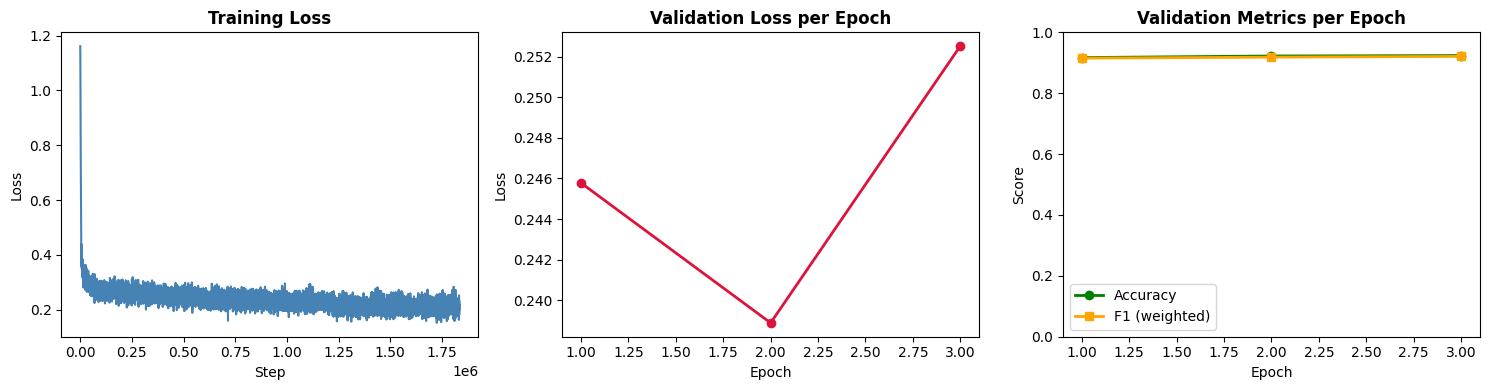

Gambar disimpan: 14_training_curve.png


In [5]:
# import json, os
# import matplotlib.pyplot as plt

# load dari trainer_state.json di checkpoint terbaru
ckpt_dirs = sorted(
    [d for d in os.listdir(PATH_MODEL) if d.startswith('checkpoint-')],
    key=lambda x: int(x.split('-')[1])
)
latest_ckpt = os.path.join(PATH_MODEL, ckpt_dirs[-1])
print(f"Checkpoint: {latest_ckpt}")

with open(os.path.join(latest_ckpt, 'trainer_state.json')) as f:
    state = json.load(f)

log_history = state['log_history']
train_logs  = [l for l in log_history if 'loss' in l and 'eval_loss' not in l]
eval_logs   = [l for l in log_history if 'eval_loss' in l]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if train_logs:
    steps  = [l['step'] for l in train_logs]
    losses = [l['loss'] for l in train_logs]
    axes[0].plot(steps, losses, color='steelblue', linewidth=1.5)
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')

if eval_logs:
    epochs_    = [l.get('epoch', i+1) for i, l in enumerate(eval_logs)]
    eval_loss_ = [l['eval_loss'] for l in eval_logs]
    eval_acc_  = [l.get('eval_accuracy', 0) for l in eval_logs]
    eval_f1_   = [l.get('eval_f1', 0) for l in eval_logs]

    axes[1].plot(epochs_, eval_loss_, 'o-', color='crimson', linewidth=2)
    axes[1].set_title('Validation Loss per Epoch', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')

    axes[2].plot(epochs_, eval_acc_, 'o-', color='green', linewidth=2, label='Accuracy')
    axes[2].plot(epochs_, eval_f1_,  's-', color='orange', linewidth=2, label='F1 (weighted)')
    axes[2].set_title('Validation Metrics per Epoch', fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Score')
    axes[2].set_ylim(0, 1)
    axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '14_training_curve.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 14_training_curve.png")

In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1':       f1_score(labels, preds, average='weighted'),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

# Reload model dari checkpoint terbaik untuk evaluasi
best_ckpt = state.get('best_model_checkpoint', latest_ckpt)
print(f"Load model dari: {best_ckpt}")

model = DistilBertForSequenceClassification.from_pretrained(best_ckpt)
model.to(DEVICE)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

eval_args = TrainingArguments(
    output_dir=PATH_MODEL,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    fp16=(DEVICE == 'cuda'),
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=eval_args,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
print("Model siap untuk evaluasi.")

Load model dari: D:\big-data-ai-sentiment\models\distilbert\checkpoint-1834947


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model siap untuk evaluasi.


## 5. Evaluasi

Evaluasi dilakukan pada validation set dan test set. Test set dipakai hanya sekali di sini — tidak boleh dipakai untuk tuning hyperparameter agar hasilnya tidak bias.

In [7]:
print("Evaluasi validation set:")
val_metrics = trainer.evaluate(val_ds)
print(f"  Loss       : {val_metrics['eval_loss']:.4f}")
print(f"  Accuracy   : {val_metrics['eval_accuracy']:.4f}  ({val_metrics['eval_accuracy']*100:.2f}%)")
print(f"  F1 (wgt)   : {val_metrics['eval_f1']:.4f}")
print(f"  F1 (macro) : {val_metrics['eval_f1_macro']:.4f}")

print("\nEvaluasi test set:")
test_metrics = trainer.evaluate(test_ds)
print(f"  Loss       : {test_metrics['eval_loss']:.4f}")
print(f"  Accuracy   : {test_metrics['eval_accuracy']:.4f}  ({test_metrics['eval_accuracy']*100:.2f}%)")
print(f"  F1 (wgt)   : {test_metrics['eval_f1']:.4f}")
print(f"  F1 (macro) : {test_metrics['eval_f1_macro']:.4f}")

Evaluasi validation set:


Training Loss,Validation Loss,Step,Accuracy,F1,F1 Macro
No log,0.252516,0,0.923597,0.920900,0.831530


  Loss       : 0.2525
  Accuracy   : 0.9236  (92.36%)
  F1 (wgt)   : 0.9209
  F1 (macro) : 0.8315

Evaluasi test set:


Training Loss,Validation Loss,Step,Accuracy,F1,F1 Macro
No log,0.252487,0,0.923504,0.920725,0.831236


  Loss       : 0.2525
  Accuracy   : 0.9235  (92.35%)
  F1 (wgt)   : 0.9207
  F1 (macro) : 0.8312


Prediksi test set...



Classification Report (test set):
              precision    recall  f1-score   support

     Negatif       0.91      0.93      0.92    242070
      Netral       0.67      0.56      0.61    103790
     Positif       0.96      0.98      0.97    702681

    accuracy                           0.92   1048541
   macro avg       0.84      0.82      0.83   1048541
weighted avg       0.92      0.92      0.92   1048541



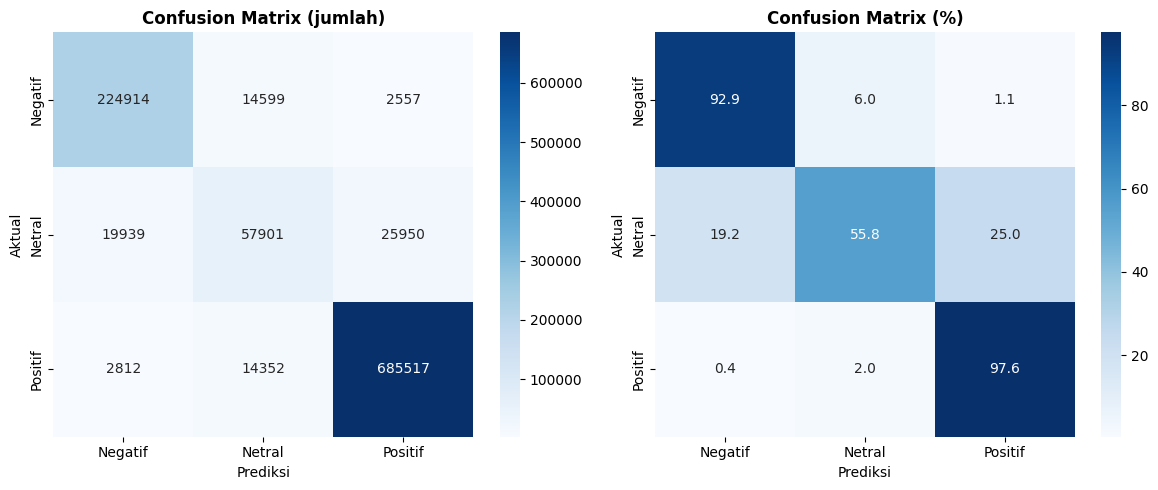

Gambar disimpan: 15_confusion_matrix.png


In [8]:
print("Prediksi test set...")
preds_out = trainer.predict(test_ds)
y_pred    = np.argmax(preds_out.predictions, axis=-1)
y_true    = preds_out.label_ids

print("\nClassification Report (test set):")
print(classification_report(
    y_true, y_pred,
    target_names=[LABEL_MAP[i] for i in range(3)]
))

cm     = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = [LABEL_MAP[i] for i in range(3)]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (jumlah)', fontweight='bold')
axes[0].set_ylabel('Aktual')
axes[0].set_xlabel('Prediksi')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Confusion Matrix (%)', fontweight='bold')
axes[1].set_ylabel('Aktual')
axes[1].set_xlabel('Prediksi')

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '15_confusion_matrix.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 15_confusion_matrix.png")

## 6. Simpan Model

In [9]:
model.save_pretrained(PATH_MODEL)
tokenizer.save_pretrained(PATH_MODEL)
print(f"Model tersimpan di    : {PATH_MODEL}")

metrics_out = {
    'model': 'distilbert-base-uncased',
    'max_length': MAX_LENGTH,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'learning_rate': LR,
    'val': {
        'loss':      round(val_metrics['eval_loss'], 4),
        'accuracy':  round(val_metrics['eval_accuracy'], 4),
        'f1_weighted': round(val_metrics['eval_f1'], 4),
        'f1_macro':  round(val_metrics['eval_f1_macro'], 4),
    },
    'test': {
        'loss':      round(test_metrics['eval_loss'], 4),
        'accuracy':  round(test_metrics['eval_accuracy'], 4),
        'f1_weighted': round(test_metrics['eval_f1'], 4),
        'f1_macro':  round(test_metrics['eval_f1_macro'], 4),
    },
}
metrics_path = os.path.join(PATH_METRICS, 'distilbert_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_out, f, indent=2)
print(f"Metrik tersimpan di   : {metrics_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model tersimpan di    : D:\big-data-ai-sentiment\models\distilbert
Metrik tersimpan di   : D:\big-data-ai-sentiment\outputs\metrics\distilbert_metrics.json


## 7. Ringkasan

In [10]:
print("=" * 60)
print("RINGKASAN TRAINING DISTILBERT")
print("=" * 60)
print(f"\nModel   : distilbert-base-uncased (fine-tuned 3 kelas)")
print(f"Epochs  : {EPOCHS}  |  Batch : {BATCH_SIZE}  |  LR : {LR}  |  max_length : {MAX_LENGTH}")
print(f"\nHasil validation set:")
print(f"  Accuracy  : {val_metrics['eval_accuracy']:.4f} ({val_metrics['eval_accuracy']*100:.2f}%)")
print(f"  F1 (wgt)  : {val_metrics['eval_f1']:.4f}")
print(f"  F1 (mac)  : {val_metrics['eval_f1_macro']:.4f}")
print(f"\nHasil test set:")
print(f"  Accuracy  : {test_metrics['eval_accuracy']:.4f} ({test_metrics['eval_accuracy']*100:.2f}%)")
print(f"  F1 (wgt)  : {test_metrics['eval_f1']:.4f}")
print(f"  F1 (mac)  : {test_metrics['eval_f1_macro']:.4f}")
print(f"\nModel disimpan   : {PATH_MODEL}")
print(f"Metrik disimpan  : {metrics_path}")
print("\nLanjut ke 05_visualization.ipynb")

RINGKASAN TRAINING DISTILBERT

Model   : distilbert-base-uncased (fine-tuned 3 kelas)
Epochs  : 3  |  Batch : 8  |  LR : 2e-05  |  max_length : 512

Hasil validation set:
  Accuracy  : 0.9236 (92.36%)
  F1 (wgt)  : 0.9209
  F1 (mac)  : 0.8315

Hasil test set:
  Accuracy  : 0.9235 (92.35%)
  F1 (wgt)  : 0.9207
  F1 (mac)  : 0.8312

Model disimpan   : D:\big-data-ai-sentiment\models\distilbert
Metrik disimpan  : D:\big-data-ai-sentiment\outputs\metrics\distilbert_metrics.json

Lanjut ke 05_visualization.ipynb
